In [1]:
import pandas as pd

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

Q1. Downloading the Data

In [2]:
df = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet")

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [4]:
len(df.columns)

19

Q2. Computing duration

In [5]:
df["duration"] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df["duration"] = df.duration.dt.total_seconds() / 60

In [6]:
df.duration.mean()

np.float64(15.612950619257845)

In [7]:
df.duration.std()

np.float64(34.85105359221282)

Q3. Dropping outliers

In [8]:
len(df[(df.duration >= 1) & (df.duration <= 60)]) / len(df) * 100

97.78326020432945

In [ ]:
df = df[(df.duration >= 1)  & (df.duration <= 60)]

Q4. One-hot encoding

In [10]:
categorical = ["PULocationID", "DOLocationID"]

In [11]:
df[categorical] = df[categorical].astype(str)

In [12]:
train_dicts = df[categorical].to_dict(orient="records")

In [13]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [14]:
print(f"Feature matrix size: {X_train.shape}")

Feature matrix size: (2898906, 518)


Q5. Training a model

In [15]:
target = "duration"
y_train = df[target].values

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = lr.predict(X_train)

print(f"Train RMSE: {root_mean_squared_error(y_train, y_pred,)}")

Train RMSE: 7.946174399640668


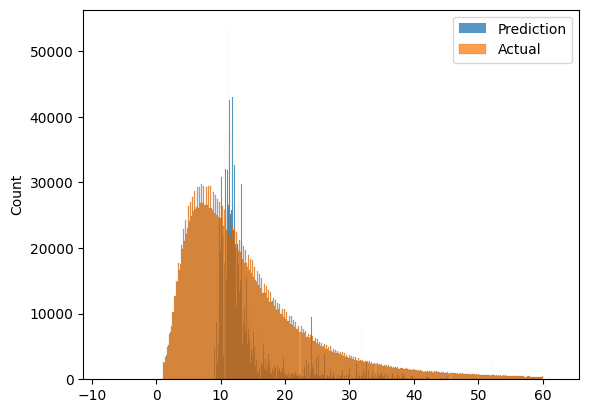

In [18]:
sns.histplot(y_pred, label="Prediction")
sns.histplot(y_train, label="Actual")

plt.legend()

Q6. Evaluating the model

In [ ]:
categorical = ["PULocationID", "DOLocationID"]

def read_data(file_path):

    df = pd.read_parquet(file_path)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    df[categorical] = df[categorical].astype('str')
    
    return df

In [ ]:
df_val = read_data("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-02.parquet")

: 

In [ ]:
val_dicts = df_val[categorical].to_dict(orient="records")

In [ ]:
X_val = dv.transform(val_dicts)
y_val = df_val.duration.values

In [ ]:
y_pred = lr.predict(X_val)

In [ ]:
print(f"Val RMSE: {root_mean_squared_error(y_val, y_pred)}")